# 01 · Binary track: healthy vs diseased

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/atilimai/plant-ai-project/blob/main/notebooks/01_binary_experiment_plan.ipynb)

Issue #03. Trains MobileNetV2 and EfficientNet-B0 on the binary track and shows the learning curves.
Use a GPU runtime (*Runtime → Change runtime type → T4 GPU*). One run takes roughly 15–30 minutes on a T4.

Labels: the 12 `*___healthy` classes → `healthy`, the other 26 → `diseased` (72% of images). Class-weighted cross-entropy (inverse square root of frequency) keeps the minority class from being ignored.

In [1]:
# Setup: on Colab clone the repo and install deps; locally just move to the repo root.
import os, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not Path("plant-ai-project").exists():
        !git clone -q https://github.com/atilimai/plant-ai-project.git
    %cd plant-ai-project
    !pip install -q -r requirements.txt
else:
    while not Path("configs/data.yaml").exists() and Path.cwd() != Path.cwd().parent:
        os.chdir("..")
sys.path.insert(0, str(Path.cwd()))
print("repo root:", Path.cwd().name)

repo root: plant-ai-project


## Configuration

All runs share `configs/train_base.yaml`; the experiment files only set the task and architecture.

In [2]:
from src.utils.config import load_config
import yaml

cfg = load_config("configs/binary_mobilenet_v2.yaml")
print(yaml.safe_dump(cfg, sort_keys=False))

seed: 42
device: auto
output_dir: models/checkpoints
data:
  manifest: data/splits/manifest.csv
  image_root: data/raw/plantvillage
  image_size: 224
  batch_size: 64
  num_workers: 8
  subset_fraction: 1.0
augmentation:
  crop_scale:
  - 0.6
  - 1.0
  right_angle_rotation: true
  color_jitter:
    brightness: 0.2
    contrast: 0.2
    saturation: 0.2
    hue: 0.02
  color_jitter_p: 0.8
model:
  pretrained: true
  dropout: 0.2
  arch: mobilenet_v2
train:
  epochs: 15
  lr: 0.001
  backbone_lr_mult: 0.3
  weight_decay: 0.05
  warmup_epochs: 1
  label_smoothing: 0.1
  class_weighting: inverse_sqrt
  grad_clip: 5.0
  amp: true
  channels_last: false
  monitor: macro_f1
  early_stopping_patience: 4
  freeze_backbone_epochs: 0
  resume: true
run_name: binary_mobilenet_v2
task: binary



## Train

Set `RUN_TRAINING = True` to train. Training resumes from `last.pt` if the runtime disconnects, so just re-run the cell.
On Colab, mounting Drive and pointing `output_dir` there keeps checkpoints across sessions:
`override = ["output_dir=/content/drive/MyDrive/plant-ai/checkpoints"]`.

The data must be prepared first (`notebooks/00_dataset_inspection.ipynb` or `python -m src.data.prepare`).

In [3]:
RUN_TRAINING = False
override = ["data.num_workers=2"] if IN_COLAB else []

if RUN_TRAINING:
    from src.training.trainer import train
    for arch in ("mobilenet_v2", "efficientnet_b0"):
        train(load_config(f"configs/binary_{arch}.yaml", override))

## Learning curves of the reference runs

These read `history.csv` from the checkpoints folder (or the copy committed under `artifacts/reports`).

binary_mobilenet_v2: best epoch 5 · val macro-F1 0.9988 · val acc 0.9991
binary_efficientnet_b0: best epoch 12 · val macro-F1 0.9997 · val acc 0.9997


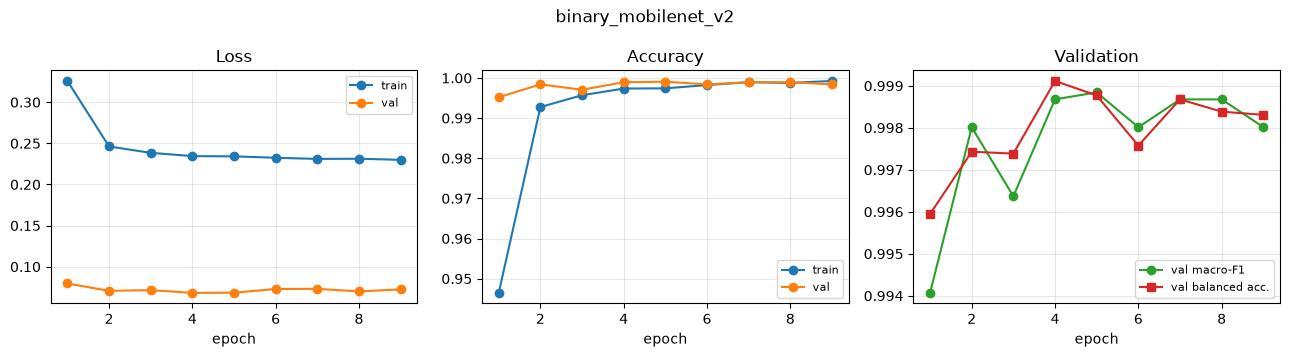

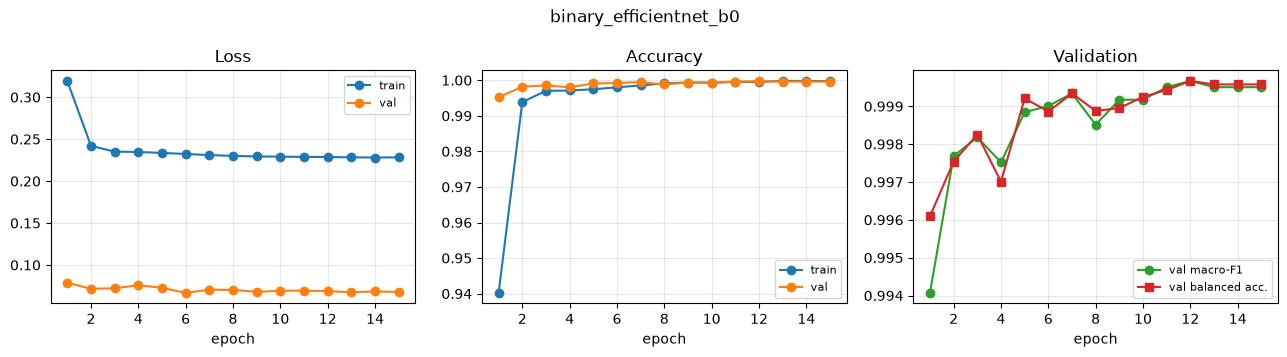

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from src.visualization.plots import plot_training_curves

%config InlineBackend.figure_formats = ["jpeg"]

for arch in ("mobilenet_v2", "efficientnet_b0"):
    run = f"binary_{arch}"
    for candidate in (Path("models/checkpoints") / run / "history.csv", Path("artifacts/reports") / run / "history.csv"):
        if candidate.exists():
            history = pd.read_csv(candidate)
            plot_training_curves(history, title=run)
            best = history.loc[history["val_macro_f1"].idxmax()]
            print(f"{run}: best epoch {int(best.epoch)} · val macro-F1 {best.val_macro_f1:.4f} · val acc {best.val_accuracy:.4f}")
            break
    else:
        print(f"{run}: no history found, train it first")
plt.show()

Validation numbers are used for model selection only. Test-set results are in `03_evaluation_plan.ipynb`.